In [16]:
import torch
from torch import nn
from d2l import torch as d2l
from good_functions import *

batch_size=256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

实现一个具有单隐藏层的多层感知机，它包含256个隐藏单元

In [17]:
num_inputs,num_outputs,num_hiddens=28*28,10,256

w1=nn.Parameter(torch.randn(num_inputs,num_hiddens,requires_grad=True)*0.01)
w2=nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad=True)*0.01)

b1=nn.Parameter(torch.zeros(num_hiddens,requires_grad=True))
b2=nn.Parameter(torch.zeros(num_outputs,requires_grad=True))

params=[w1,b1,w2,b2]

这些代码相当于给w1,w2,b1,b2进行初始化

实现ReLU激活函数

In [18]:
def relu(X):
    a=torch.zeros_like(X)
    return torch.max(X,a)

实现我们的模型

In [19]:
def net(X):
    X=X.reshape(-1,28*28)
    H=relu(X@w1+b1)
    return (H@w2+b2)

loss=nn.CrossEntropyLoss()

训练！

training done — loss 0.3210, train acc 0.8845, test acc 0.8674


(0.3209741717497508, 0.8844833333333333)

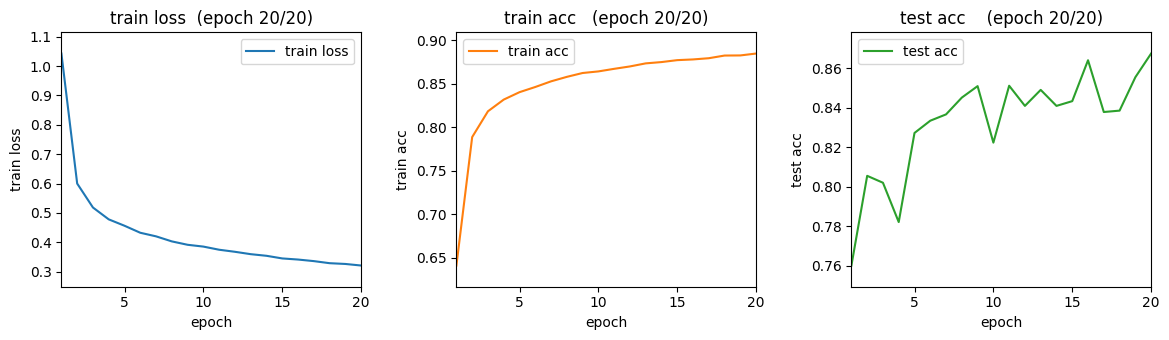

In [20]:
num_epochs,lr=(10,0.1)
updater=torch.optim.SGD(params,lr=lr)
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)